<hr>

# 📈 DATA ANALYSIS


<style>
h1 {
    text-align: left;
    color: blue;
    font-weight: bold;
}

</style>
<hr>

```text
Types of Analysis:
- Univariat
- Bivariat (feature vs target)
- Multivariat (mulitple feautures vs target)
- Correlation Matrix
- Outliers
```

<style>
h3 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

### 📂 IMPORTs

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200) # to display all columns in the dataframe

<hr>

## 0 - DATA OBSERVATION


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

### **SHAPE & HEAD**

In [ ]:
import pandas as pd

FILE = "../data/processed/CLEAN_ValeursFoncieres.csv"
CHUNK_SIZE = 50_000

total_rows = 0
columns = None

for chunk in pd.read_csv(FILE, chunksize=CHUNK_SIZE, dtype=str):
    total_rows += len(chunk)
    if columns is None:
        columns = chunk.columns

print("Shape:", total_rows, "rows and", len(columns), "columns")

df_head = pd.read_csv(FILE, nrows=5, dtype=str)
display(df_head)


### **INFO**

In [ ]:
import pandas as pd

FILE = "../data/processed/CLEAN_ValeursFoncieres.csv"
CHUNK_SIZE = 50_000

total_rows = 0
columns = None
non_null_counts = None
dtypes = None

for chunk in pd.read_csv(FILE, chunksize=CHUNK_SIZE, dtype=str):
    if columns is None:
        columns = chunk.columns.tolist()
        non_null_counts = {col: 0 for col in columns}
        dtypes = chunk.dtypes.astype(str).to_dict()

    total_rows += len(chunk)

    for col in columns:
        non_null_counts[col] += chunk[col].notna().sum()

# Build info-style summary
info_df = pd.DataFrame({
    "column": columns,
    "non_null_count": [non_null_counts[col] for col in columns],
    "null_count": [total_rows - non_null_counts[col] for col in columns],
    "dtype": [dtypes[col] for col in columns]
})

print(f"RangeIndex: {total_rows} entries, 0 to {total_rows - 1}")
print(f"Data columns (total {len(columns)} columns):")
display(info_df)
print(f"dtypes: {info_df['dtype'].value_counts().to_dict()}")
print(f"memory usage: not computed (chunked mode)")

### **UNIQUE VALUES**

In [ ]:
from collections import defaultdict
import pandas as pd

FILE = "../data/processed/CLEAN_ValeursFoncieres.csv"

unique_values = defaultdict(set)
null_counts = defaultdict(int)

for chunk in pd.read_csv(FILE, chunksize=50_000, dtype=str):
    for col in chunk.columns:
        null_counts[col] += chunk[col].isna().sum()
        unique_values[col].update(chunk[col].fillna("MISSING").unique())

print(100*"-")
for col in unique_values:
    print(f"\n➡️ {col}:")
    print(f"Unique values count:{len(unique_values[col])}")
    print(f"Null count: {null_counts[col]}")
    print(f"Unique values: {list(unique_values[col])[:120]}")
    print(100*"-")

### 🆔 **IDENTIFY - Numerical / Categorical Columns**

In [ ]:
# Define columns numerical / categorical

num_cols = [
    '', 
    'col_5', 
    'col_6'
]

cat_cols = [
    'col_1',
    'col_2',
    'col_4'
]


# Display NUMERICAL and CATEGORICAL COLUMNS
print("Numerical columns:")
display(num_cols)
print(100*"-")

print("Categorical columns:")
display(cat_cols)
print(100*"-")

print("Date columns:")
display(date_cols)
print(100*"-")


<hr>

## 1 - UNIVARIAT ANALYSIS


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

It's the simplest form of data analysis that deals with only one variable at a time, either in an inferential or descriptive manner

<hr>

## 2 - BIVARIAT ANALYSIS


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

It's a statistical technique used to analyze the relationship between two variables

<style>
h3 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
    color: black;
}
</style>

### A) FEATURE vs TARGET (transaction_value)

<style>
h4 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

#### 🏷️ Categorical vs 🎯 Target

<style>
h4 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

#### 🔢 Numerical vs 🎯 Target

<style>
h3 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
    color: black;
}
</style>

### B) FEATURE vs FEATURE

<style>
h4 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

#### 🏷️ Categorical vs 🏷️ Categorical

<style>
h4 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

#### 🔢 Numerical vs 🔢 Numerical

<style>
h4 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

#### 🏷️ Categorical vs 🔢 Numerical (vice versa)

<hr>

## 3 - MULTIVARIAT ANALYSIS


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

It's a collection of statistical techniques used to analyze data sets with multiple correlated variables

### **ALL FEATURES vs TARGET `transaction_value`**

In [ ]:
# scatter plot each feature vs target variable

In [ ]:
# correlation matrix heatmap plot

<hr>

## 4 - OUTLIERS ANALYSIS


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

 An outlier is an observation that lies an abnormal distance from other values in a random sample from a population

<hr>

## 5 - CORRELATION ANALYSIS


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

It's a statistical method that is used to discover if there is a relationship between two variables/datasets, and how strong that relationship may be

<hr>

## TRENDS


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

#### **PLOT : Linear chart for 5-6 years TRENDS(Date mutation) Type local(line coloured) vs Valeur fonciere(y-axis)**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert date
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

# Keep only useful rows
df = df.dropna(subset=["property_value", "property_type"])

# Optional: remove extreme outliers (recommended)
df = df[df["property_value"] < 2_000_000]

# Create year-month column
df["year_month"] = df["transaction_date"].dt.to_period("M")

# Aggregate: mean price per month per property type
df_grouped = df.groupby(["year_month", "property_type"])["property_value"].mean().reset_index()

# Convert back to timestamp for plotting
df_grouped["year_month"] = df_grouped["year_month"].dt.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))

for property_type in df_grouped["property_type"].unique():
    subset = df_grouped[df_grouped["property_type"] == property_type]
    plt.plot(subset["year_month"], subset["property_value"], label=property_type)

plt.xlabel("Date")
plt.ylabel("Average Property Price (€)")
plt.title("Property Price and Type 2020-2025")
plt.legend()
plt.grid()

plt.show()

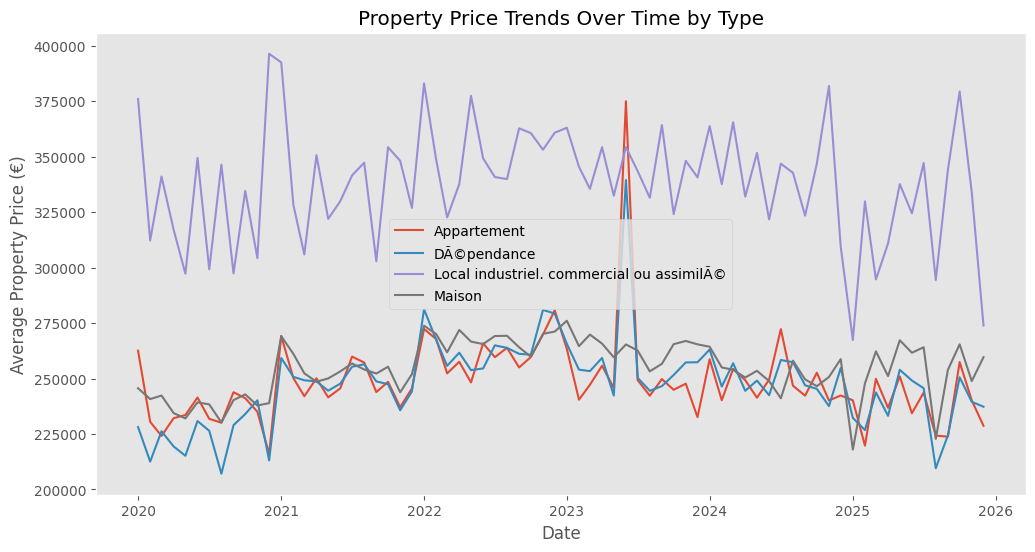

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert date
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only useful rows
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers (recommended)
df = df[df["Valeur fonciere"] < 2_000_000]

# Create year-month column
df["year_month"] = df["Date mutation"].dt.to_period("M")

# Aggregate: mean price per month per property type
df_grouped = df.groupby(["year_month", "Type local"])["Valeur fonciere"].mean().reset_index()

# Convert back to timestamp for plotting
df_grouped["year_month"] = df_grouped["year_month"].dt.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))

for property_type in df_grouped["Type local"].unique():
    subset = df_grouped[df_grouped["Type local"] == property_type]
    plt.plot(subset["year_month"], subset["Valeur fonciere"], label=property_type)

plt.xlabel("Date")
plt.ylabel("Average Property Price (€)")
plt.title("Property Price Trends Over Time by Type")
plt.legend()
plt.grid()

plt.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Convert date
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant rows
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Filter only Maison & Appartement
df = df[df["Type local"].isin(["Maison", "Appartement"])]

# Create year-month column
df["year_month"] = df["Date mutation"].dt.to_period("M")
df_grouped = df.groupby(["year_month", "Type local"])["Valeur fonciere"].mean().reset_index()

# Convert back to timestamp for plotting
df_grouped["year_month"] = df_grouped["year_month"].dt.to_timestamp()

# Colors for property types
colors = {'Maison': '#4C78A8', 'Appartement': '#F58518'}

# Plotly figure
fig = go.Figure()
for prop_type in ["Maison", "Appartement"]:
    subset = df_grouped[df_grouped["Type local"] == prop_type]
    fig.add_trace(go.Scatter(
        x=subset["year_month"],
        y=subset["Valeur fonciere"],
        mode='lines+markers',
        name=prop_type,
        line=dict(color=colors[prop_type], width=3),
        marker=dict(size=8),
        hovertemplate=f'<b>{prop_type}</b><br>Date: %{{x|%b %Y}}<br>Avg Price: €%{{y:,.0f}}<extra></extra>'
    ))

fig.update_layout(
    title='Property Price Trends Over Time by Type',
    xaxis_title="Date",
    yaxis_title="Average Property Price (€)",
    hovermode='x unified',
    legend=dict(title="Property Type", yanchor="top", y=1.0, xanchor="left", x=1.02),
    width=1200,
    height=600,
    plot_bgcolor='white',
    font=dict(size=12)
)

fig.update_xaxes(showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')

fig.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Convert date column
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Extract month name
df['Month_Name'] = df['Date mutation'].dt.month_name()

# Calculate average price per month for each Type local
monthly_avg = df.groupby(['Type local', 'Month_Name'])['Valeur fonciere'].mean().reset_index()

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Sort by month order
monthly_avg['Month_Name'] = pd.Categorical(monthly_avg['Month_Name'], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values('Month_Name')

# Prepare Plotly colors (soft, distinct)
colors_palette = [
    '#4C78A8', '#F58518', '#E45756', '#72B7A3', '#54A24B', '#EECA3B',
    '#B279A2', '#FF9DA7', '#9D755D', '#BAB0AC', '#8EBA42', '#4DBBD5'
]
property_types = monthly_avg['Type local'].unique()
colors = {ptype: colors_palette[i % len(colors_palette)] for i, ptype in enumerate(property_types)}

# Plotly figure
fig = go.Figure()
for prop_type in property_types:
    subset = monthly_avg[monthly_avg['Type local'] == prop_type]
    fig.add_trace(go.Scatter(
        x=subset['Month_Name'],
        y=subset['Valeur fonciere'],
        mode='lines+markers',
        name=prop_type,
        line=dict(color=colors[prop_type], width=3),
        marker=dict(size=8),
        hovertemplate=f'<b>{prop_type}</b><br>Month: %{{x}}<br>Avg Price: €%{{y:,.0f}}<extra></extra>'
    ))

fig.update_layout(
    title='Seasonal Trends: Average Property Price per Month (5-Year Avg)',
    xaxis_title="Month",
    yaxis_title="Average Property Price (€)",
    hovermode='x unified',
    legend=dict(title="Property Type", yanchor="top", y=1.0, xanchor="left", x=1.02),
    width=1200,
    height=600,
    plot_bgcolor='white',
    font=dict(size=12)
)

fig.update_xaxes(tickangle=0)
fig.update_yaxes(showgrid=True, gridcolor='lightgray')

fig.show()

# Optional: print the monthly averages table
print("Monthly averages across 5 years:")
print(monthly_avg.pivot(index='Month_Name', columns='Type local', values='Valeur fonciere').round(0))

Monthly averages across 5 years:
Type local  Appartement    Maison
Month_Name                       
January        266449.0  266889.0
February       247497.0  259443.0
March          245315.0  257244.0
April          249979.0  255971.0
May            243792.0  255363.0
June           280849.0  256385.0
July           254879.0  257358.0
August         251298.0  254998.0
September      246545.0  253474.0
October        250666.0  255920.0
November       247866.0  255282.0
December       247065.0  259165.0


#### **PLOT : Linear chart 2020-2025 PROPERTY_TYPE/PRICE TRENDS (price per m²)**

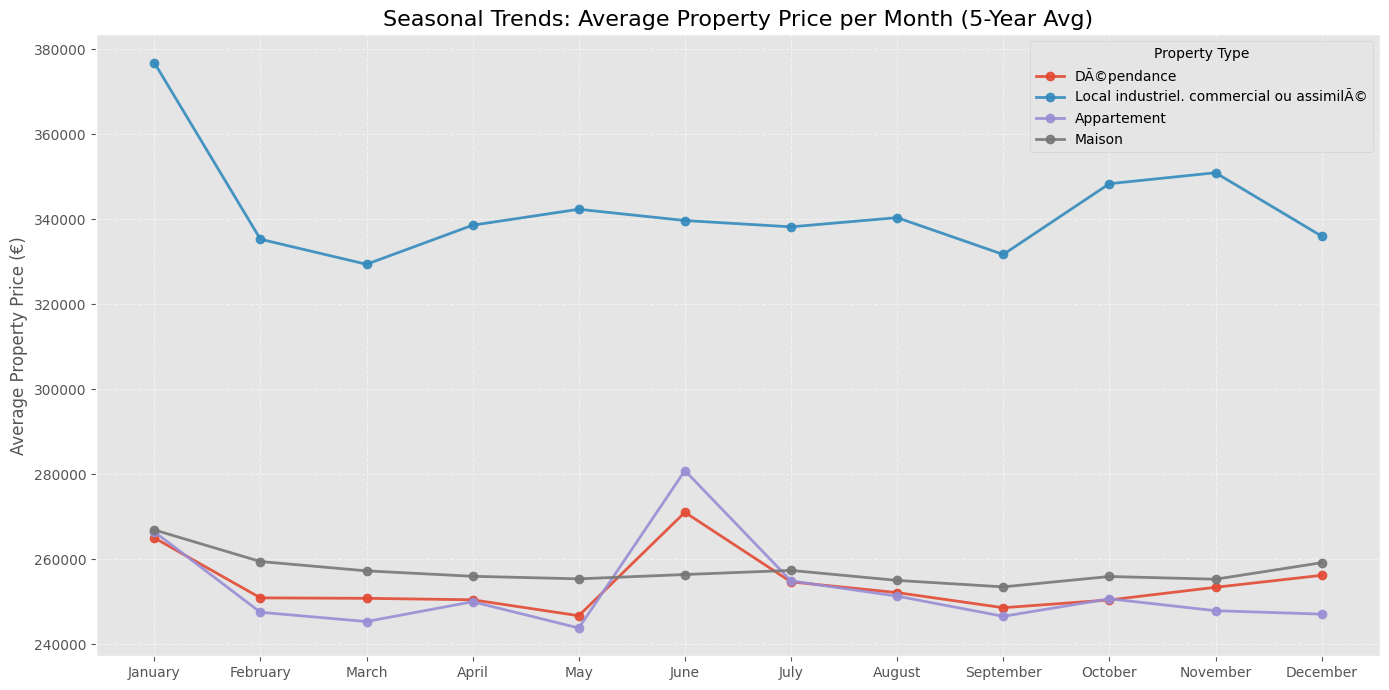

Monthly averages across 5 years:
Type local  Appartement  DÃ©pendance  \
Month_Name                             
January        266449.0     265015.0   
February       247497.0     250887.0   
March          245315.0     250781.0   
April          249979.0     250435.0   
May            243792.0     246682.0   
June           280849.0     271031.0   
July           254879.0     254650.0   
August         251298.0     252130.0   
September      246545.0     248569.0   
October        250666.0     250399.0   
November       247866.0     253379.0   
December       247065.0     256194.0   

Type local  Local industriel. commercial ou assimilÃ©    Maison  
Month_Name                                                       
January                                      376903.0  266889.0  
February                                     335323.0  259443.0  
March                                        329423.0  257244.0  
April                                        338628.0  255971.0  
May       

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert date column
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Extract month name
df['Month_Name'] = df['Date mutation'].dt.month_name()

# Calculate average price per month for each Type local
monthly_avg = df.groupby(['Type local', 'Month_Name'])['Valeur fonciere'].mean().reset_index()

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Sort by month order
monthly_avg['Month_Name'] = pd.Categorical(monthly_avg['Month_Name'], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values('Month_Name')

# Plot
plt.figure(figsize=(14,7))
for property_type in monthly_avg['Type local'].unique():
    subset = monthly_avg[monthly_avg['Type local'] == property_type]
    plt.plot(subset['Month_Name'], subset['Valeur fonciere'],
             marker='o', linewidth=2, alpha=0.9, label=property_type)

plt.title("Seasonal Trends: Average Property Price per Month (5-Year Avg)", fontsize=16)
plt.ylabel("Average Property Price (€)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Property Type")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: print the monthly averages table
print("Monthly averages across 5 years:") # seasonal trends 
print(monthly_avg.pivot(index='Month_Name', columns='Type local', values='Valeur fonciere').round(0))

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Convert date column
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Extract month name
df['Month_Name'] = df['Date mutation'].dt.month_name()

# Calculate average price per month for each Type local
monthly_avg = df.groupby(['Type local', 'Month_Name'])['Valeur fonciere'].mean().reset_index()

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Sort by month order
monthly_avg['Month_Name'] = pd.Categorical(monthly_avg['Month_Name'], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values('Month_Name')

# Unique property types
property_types = monthly_avg['Type local'].unique()

# Eye-friendly colors (repeat if more types than colors)
colors_palette = [
    '#4C78A8', '#F58518', '#E45756', '#72B7A3', '#54A24B', '#EECA3B',
    '#B279A2', '#FF9DA7', '#9D755D', '#BAB0AC', '#8EBA42', '#4DBBD5'
]
colors = {ptype: colors_palette[i % len(colors_palette)] for i, ptype in enumerate(property_types)}

# Create Plotly figure
fig = go.Figure()
for prop_type in property_types:
    subset = monthly_avg[monthly_avg['Type local'] == prop_type]
    fig.add_trace(go.Scatter(
        x=subset['Month_Name'],
        y=subset['Valeur fonciere'],
        mode='lines+markers',
        name=prop_type,
        line=dict(color=colors[prop_type], width=3),
        marker=dict(size=8),
        hovertemplate=f'<b>{prop_type}</b><br>Month: %{{x}}<br>Avg Price: €%{{y:,.0f}}<extra></extra>'
    ))

# Update layout to match Matplotlib style
fig.update_layout(
    title='Seasonal Trends: Average Property Price per Month (5-Year Avg)',
    xaxis_title="Month",
    yaxis_title="Average Property Price (€)",
    hovermode='x unified',
    legend=dict(title="Property Type", yanchor="top", y=1.0, xanchor="left", x=1.02),
    width=1200,
    height=600,
    plot_bgcolor='white',
    font=dict(size=12)
)

fig.update_xaxes(tickangle=0, showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')

fig.show()

# Optional: print the monthly averages table
print("Monthly averages across 5 years:")
print(monthly_avg.pivot(index='Month_Name', columns='Type local', values='Valeur fonciere').round(0))

Monthly averages across 5 years:
Type local  Appartement    Maison
Month_Name                       
January        266449.0  266889.0
February       247497.0  259443.0
March          245315.0  257244.0
April          249979.0  255971.0
May            243792.0  255363.0
June           280849.0  256385.0
July           254879.0  257358.0
August         251298.0  254998.0
September      246545.0  253474.0
October        250666.0  255920.0
November       247866.0  255282.0
December       247065.0  259165.0


#### **PLOT : PURCHASE AVG Maison vs Appartement**
Linear chart MONTHLY TRENDS PROPERTY_TYPE/PRICE TRENDS (MAISON vs APPARTEMENT)

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Convert date column
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Extract month name
df['Month_Name'] = df['Date mutation'].dt.month_name()

# Calculate average price per month for each Type local
monthly_avg = df.groupby(['Type local', 'Month_Name'])['Valeur fonciere'].mean().reset_index()

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Sort by month order
monthly_avg['Month_Name'] = pd.Categorical(monthly_avg['Month_Name'], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values('Month_Name')

# Get all unique property types in dataset
property_types = monthly_avg['Type local'].unique()

# Eye-friendly colors (repeat if more types than colors)
colors_palette = [
    '#4C78A8', '#F58518', '#E45756', '#72B7A3', '#54A24B', '#EECA3B',
    '#B279A2', '#FF9DA7', '#9D755D', '#BAB0AC', '#8EBA42', '#4DBBD5'
]
colors = {ptype: colors_palette[i % len(colors_palette)] for i, ptype in enumerate(property_types)}

# Plotly figure
fig = go.Figure()
for prop_type in property_types:
    subset = monthly_avg[monthly_avg['Type local'] == prop_type]
    fig.add_trace(go.Scatter(
        x=subset['Month_Name'],
        y=subset['Valeur fonciere'],
        mode='lines+markers',
        name=prop_type,
        line=dict(color=colors[prop_type], width=3),
        marker=dict(size=8),
        hovertemplate=f'<b>{prop_type}</b><br>Month: %{{x}}<br>Avg Price: €%{{y:,.0f}}<extra></extra>'
    ))

# Layout
fig.update_layout(
    title='Seasonal Trends: Average Property Price per Month (5-Year Avg) — All Property Types',
    xaxis_title="Month",
    yaxis_title="Average Property Price (€)",
    hovermode='x unified',
    legend=dict(title="Property Type", yanchor="top", y=1.0, xanchor="left", x=1.02),
    width=1200,
    height=600,
    plot_bgcolor='white',
    font=dict(size=12)
)

fig.update_xaxes(tickangle=0, showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')

fig.show()

# Optional: print the monthly averages table
print("Monthly averages across 5 years:")
print(monthly_avg.pivot(index='Month_Name', columns='Type local', values='Valeur fonciere').round(0))

Monthly averages across 5 years:
Type local  Appartement    Maison
Month_Name                       
January        266449.0  266889.0
February       247497.0  259443.0
March          245315.0  257244.0
April          249979.0  255971.0
May            243792.0  255363.0
June           280849.0  256385.0
July           254879.0  257358.0
August         251298.0  254998.0
September      246545.0  253474.0
October        250666.0  255920.0
November       247866.0  255282.0
December       247065.0  259165.0


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Convert date
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Filter only Maison & Appartement
df = df[df["Type local"].isin(["Maison", "Appartement"])]

# Extract month names and short names
full_to_short = {
    'January': 'Jan', 'February': 'Feb', 'March': 'Mar', 'April': 'Apr',
    'May': 'May', 'June': 'Jun', 'July': 'Jul', 'August': 'Aug',
    'September': 'Sep', 'October': 'Oct', 'November': 'Nov', 'December': 'Dec'
}
df['Month_Name'] = df['Date mutation'].dt.month_name()
df['Month_Short'] = df['Month_Name'].map(full_to_short)

# Define month order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Compute 5-year monthly averages per property type
monthly_data = {}
for prop_type in ["Maison", "Appartement"]:
    monthly_avg = df[df["Type local"] == prop_type].groupby("Month_Short")["Valeur fonciere"].mean().reset_index()
    monthly_avg['Month_Short'] = pd.Categorical(monthly_avg['Month_Short'], categories=month_order, ordered=True)
    monthly_avg = monthly_avg.sort_values("Month_Short")
    monthly_data[prop_type] = monthly_avg.set_index("Month_Short")["Valeur fonciere"]

# Combine into DataFrame
monthly_df = pd.DataFrame(monthly_data).reindex(month_order)

# Colors for the two types
colors = ['#4C78A8', '#F58518']  # Maison = blue, Appartement = orange

# Plotly figure
fig = go.Figure()
for i, prop_type in enumerate(["Maison", "Appartement"]):
    fig.add_trace(go.Scatter(
        x=monthly_df.index,
        y=monthly_df[prop_type],
        mode='lines+markers',
        name=prop_type,
        line=dict(color=colors[i], width=3),
        marker=dict(size=8),
        hovertemplate=f'<b>{prop_type}</b><br>Month: %{{x}}<br>Avg Price: €%{{y:,.0f}}<extra></extra>'
    ))

fig.update_layout(
    title='Property Price Trends - Seasonal 5-Year Monthly Averages',
    xaxis_title="",
    yaxis_title="Average Property Price (€)",
    hovermode='x unified',
    legend=dict(title="Property Type", yanchor="top", y=1.0, xanchor="left", x=1.02),
    width=1200,
    height=600,
    plot_bgcolor='white',
    font=dict(size=12)
)

fig.update_xaxes(tickangle=0)
fig.update_yaxes(gridcolor='lightgray')

fig.show()

# Optional: print monthly averages table
print("✅ Seasonal 5-Year Monthly Averages (Maison & Appartement):")
print(monthly_df.round(0))

✅ Seasonal 5-Year Monthly Averages (Maison & Appartement):
               Maison  Appartement
Month_Short                       
Jan          266889.0     266449.0
Feb          259443.0     247497.0
Mar          257244.0     245315.0
Apr          255971.0     249979.0
May          255363.0     243792.0
Jun          256385.0     280849.0
Jul          257358.0     254879.0
Aug          254998.0     251298.0
Sep          253474.0     246545.0
Oct          255920.0     250666.0
Nov          255282.0     247866.0
Dec          259165.0     247065.0


#### **PLOT : RENTAL AVG Maison vs Appartement**
Linear chart MONTHLY TRENDS type/rent_price